In [45]:
import numpy  as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

from scipy.interpolate import interp1d

from nbtools import auto_plot_style

%matplotlib inline
auto_plot_style()

In [51]:
def draw_cone():
    points = np.array([
        [-16.,    0.],
        [-16., - 10.],
        [-136, -120.],
        [ 136, -120.],
        [ 16., - 10.],
        [ 16.,    0.],
    ])
    
    ticks      = np.arange(-120, 1, 20)
    ticklabels = list(map(str, -ticks))
    plt.yticks(ticks, ticklabels)
    p = Polygon(points, closed=True, facecolor="None", edgecolor="r")
    plt.gca().add_patch(p)

In [59]:
filename = "/home/gonzalo/data/COLINA/pCOLINA_triangular_efield_ring_degrad_4.5_form_factor_1.txt"
filename = "/home/gonzalo/data/COLINA/pCOLINA_triangular_efield_ring_degrad_3.75_form_factor_1.txt"

lines = np.loadtxt(filename, comments="%")[:, :3]
lines = pd.DataFrame(lines*1e3, columns="r z line".split())
lines = lines.astype(dict(line=int))
lines = lines.groupby("line").filter(lambda df: df.z.min() < -119)
lines = lines.groupby("line").filter(lambda df: df.z.max() >   -1)
lines

,r,z,line
8367,115.688859,-1.200000e+02,27000
8368,115.691621,-1.199271e+02,27000
8369,115.697737,-1.197828e+02,27000
8370,115.699312,-1.197487e+02,27000
8371,115.703740,-1.196580e+02,27000
...,...,...,...
226956,0.065849,-2.892701e-01,183000
226957,0.065720,-1.827661e-01,183000
226958,0.065592,-7.585265e-02,183000
226959,0.065562,-5.022142e-02,183000


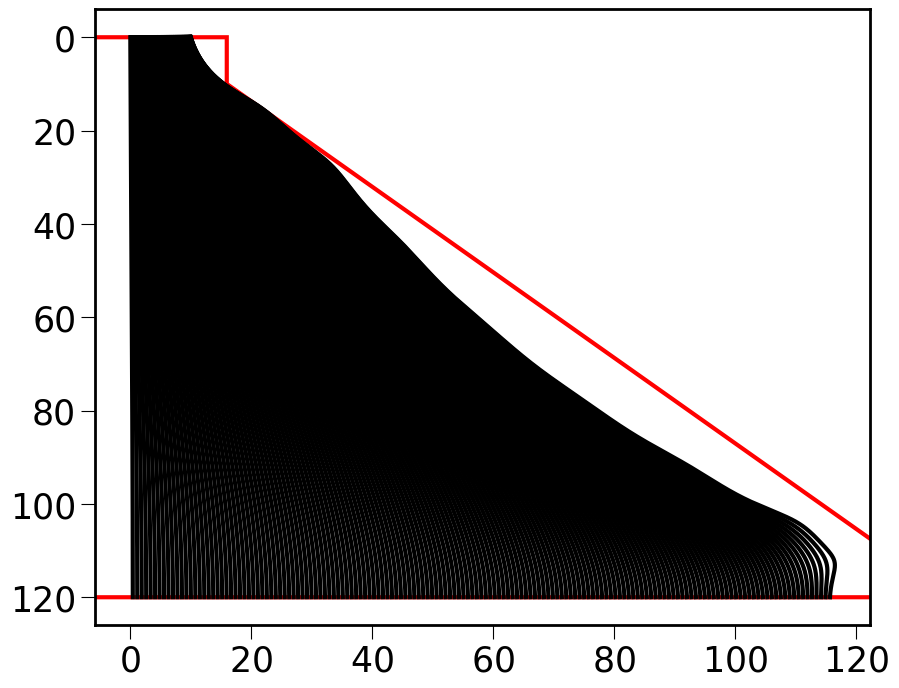

In [60]:
for _, line in lines.groupby("line"):
    plt.plot(line.r, line.z, "k-")

draw_cone()

In [61]:
anode = lines.groupby("line").last().reset_index()

In [62]:
def find_line(x):
    i = np.argmin(np.abs(anode.r.values - np.abs(x)))
    return lines.loc[lines.line == anode.line.iloc[i]]

def interpolate(line, z):
    return interp1d(line.z, line.r, kind="linear", bounds_error=False, fill_value="extrapolate")(z)

#### ignore

In [63]:
reco = pd.DataFrame([[-15.03999634,   1.69299653,   8.90177205],
                     [-14.37181362,   0.505759  ,   9.03648419],
                     [-13.50725832,   0.28077306,  10.8405823 ],
                     [-12.51528311,  -0.35817369,  12.2186859 ],
                     [-11.49744429,  -1.00595343,  13.78360887],
                     [-10.49786732,  -1.50001269,  14.76621476],
                     [ -9.49015661,  -2.60704498,  13.49031319],
                     [ -8.51244281,  -3.6554487 ,   9.72612148],
                     [ -7.48893522,  -4.29475244,   9.59166852],
                     [ -6.50175008,  -4.07332826,   8.45076635],
                     [ -5.5043442 ,  -5.43158845,   8.47411409],
                     [ -4.48804904,  -5.94259108,   9.31565895],
                     [ -3.51172708,  -5.98946267,  10.68114131],
                     [ -2.49620643,  -6.16610288,   9.93142099],
                     [ -1.50075689,  -6.63338859,   8.1648177 ],
                     [ -0.5012074 ,  -6.58350311,   6.73771628],
                     [  0.49634175,  -6.45021542,   7.35451277],
                     [  1.47674396,  -7.139851  ,   6.96306607],
                     [  2.49313444,  -9.57377778,   6.62736175],
                     [  3.49194275,  -9.0470753 ,   6.50104516],
                     [  4.50582311,  -8.59872972,   6.80756919],
                     [  5.49733811,  -8.16455982,   5.73894365],
                     [  6.49532723,  -8.7350445 ,   4.35698059],
                     [  7.48322348,  -8.16888366,   4.53670425],
                     [  8.49917005,  -9.22719193,   4.05338519],
                     [  9.51131445, -13.35861686,   3.09739778],
                     [ 10.49701115, -13.57562747,   1.74332166],
                     [ 11.50103434, -12.92946504,   1.64485088],
                     [ 12.49254822, -13.20770026,   0.71415442],
                     [ 13.50059268, -10.45737104,   0.75639183],
                     [ 14.37567496,  -8.56101061,   0.77843065],
                     [ 15.05094092,  -6.5594151 ,  -0.40787162]], columns="anode anode_lower anode_upper".split())

reco.loc[:, "anode_lower"] = reco.anode + reco.anode_lower
reco.loc[:, "anode_upper"] = reco.anode + reco.anode_upper
reco = reco.iloc[1:-1]
reco

,anode,anode_lower,anode_upper
1,-14.371814,-13.866055,-5.335329
2,-13.507258,-13.226485,-2.666676
3,-12.515283,-12.873457,-0.296597
4,-11.497444,-12.503398,2.286165
5,-10.497867,-11.997880,4.268347
6,-9.490157,-12.097202,4.000157
7,-8.512443,-12.167892,1.213679
8,-7.488935,-11.783688,2.102733
9,-6.501750,-10.575078,1.949016
10,-5.504344,-10.935933,2.969770


In [64]:
reco = pd.DataFrame([[-15.03999634,   2.10911983,   4.81543008],
                     [-14.37181362,   1.74844976,   6.00943742],
                     [-13.50725832,   1.74279168,   7.09830693],
                     [-12.51528311,   1.65258061,   8.1593037 ],
                     [-11.49744429,   1.20741714,   9.1008997 ],
                     [-10.49786732,   0.98552086,   9.55882738],
                     [ -9.49015661,  -0.21235271,   6.98284327],
                     [ -8.51244281,  -1.41976755,   5.10790249],
                     [ -7.48893522,  -1.57627011,   4.93140472],
                     [ -6.50175008,  -1.49506059,   5.11047269],
                     [ -5.5043442 ,  -2.50889218,   4.46956173],
                     [ -4.48804904,  -3.50594181,   4.72022894],
                     [ -3.51172708,  -2.90859929,   5.993777  ],
                     [ -2.49620643,  -3.16711837,   5.71250367],
                     [ -1.50075689,  -3.6436455 ,   4.05768215],
                     [ -0.5012074 ,  -3.69909361,   3.63041939],
                     [  0.49634175,  -3.15627431,   4.45551938],
                     [  1.47674396,  -3.16510309,   4.14561527],
                     [  2.49313444,  -5.09646881,   3.39279469],
                     [  3.49194275,  -4.76206976,   3.68151357],
                     [  4.50582311,  -3.94905912,   3.96520898],
                     [  5.49733811,  -4.29663618,   3.14271079],
                     [  6.49532723,  -4.44991722,   1.96620906],
                     [  7.48322348,  -4.30775692,   2.14846302],
                     [  8.49917005,  -4.86539215,   1.92877151],
                     [  9.51131445,  -6.71250803,   0.57262617],
                     [ 10.49701115,  -8.81773452,  -0.6213468 ],
                     [ 11.50103434,  -8.37182671,  -0.62797491],
                     [ 12.49254822,  -8.21560288,  -1.10727976],
                     [ 13.50059268,  -6.42149676,  -1.17022459],
                     [ 14.37567496,  -5.36250144,  -0.86621442],
                     [ 15.05094092,  -5.61371161,  -2.09858625]], columns="anode anode_lower anode_upper".split())

reco.loc[:, "anode_lower"] = reco.anode + reco.anode_lower
reco.loc[:, "anode_upper"] = reco.anode + reco.anode_upper
reco = reco.iloc[1:-1]
reco

,anode,anode_lower,anode_upper
1,-14.371814,-12.623364,-8.362376
2,-13.507258,-11.764467,-6.408951
3,-12.515283,-10.862703,-4.355979
4,-11.497444,-10.290027,-2.396545
5,-10.497867,-9.512346,-0.939040
6,-9.490157,-9.702509,-2.507313
7,-8.512443,-9.932210,-3.404540
8,-7.488935,-9.065205,-2.557531
9,-6.501750,-7.996811,-1.391277
10,-5.504344,-8.013236,-1.034782


# 1 Sigma

In [66]:
reco = pd.DataFrame([[-17.1391518 ,  -1.26121149,  -1.26121149],
                     [-15.32894212,  -3.50614061,  -0.05325391],
                     [-14.36728003,  -2.72379925,   1.34571251],
                     [-13.44477218,  -2.4464608 ,   2.03306325],
                     [-12.47527802,  -2.63772554,   2.7700798 ],
                     [-11.47804947,  -3.36877768,   3.13846938],
                     [-10.49651759,  -3.56070313,   3.90660796],
                     [ -9.50458481,  -3.77708473,   4.14902474],
                     [ -8.4870552 ,  -3.61565777,   4.43851141],
                     [ -7.49695373,  -3.90689616,   4.44046688],
                     [ -6.50115987,  -3.98817107,   4.49792593],
                     [ -5.50625221,  -4.10988092,   4.74604945],
                     [ -4.5043262 ,  -4.67696396,   5.33731622],
                     [ -3.50226384,  -4.60673305,   5.35947067],
                     [ -2.50537871,  -5.01403285,   5.6297858 ],
                     [ -1.49440536,  -5.01574428,   5.74067908],
                     [ -0.50103838,  -4.9420004 ,   6.37869316],
                     [  0.49385115,  -5.40353042,   6.15844956],
                     [  1.49659087,  -5.19166779,   5.64719581],
                     [  2.49186029,  -4.45976754,   5.8631252 ],
                     [  3.49831263,  -4.69776866,   5.37173521],
                     [  4.49211287,  -4.64472301,   4.85090248],
                     [  5.4984623 ,  -4.5108319 ,   4.64236869],
                     [  6.49515119,  -4.2158137 ,   5.07528149],
                     [  7.5026601 ,  -4.1501357 ,   4.72245804],
                     [  8.49457777,  -3.7973723 ,   4.68222896],
                     [  9.4970227 ,  -3.70647237,   4.55020777],
                     [ 10.5088403 ,  -3.40680472,   4.22720325],
                     [ 11.4943439 ,  -3.18295537,   3.72216213],
                     [ 12.47915547,  -2.41988961,   3.67041061],
                     [ 13.45884235,  -1.80467411,   2.98830892],
                     [ 14.45756016,  -1.219269  ,   2.65605129],
                     [ 15.38871433,  -0.32219432,   3.79737813],
                     [ 16.39732966,   0.44956398,   3.98175942]], columns="anode anode_lower anode_upper".split())

reco.loc[:, "anode_lower"] = reco.anode + reco.anode_lower
reco.loc[:, "anode_upper"] = reco.anode + reco.anode_upper
reco = reco.iloc[1:-1]
reco

,anode,anode_lower,anode_upper
1,-15.328942,-18.835083,-15.382196
2,-14.367280,-17.091079,-13.021568
3,-13.444772,-15.891233,-11.411709
4,-12.475278,-15.113004,-9.705198
5,-11.478049,-14.846827,-8.339580
6,-10.496518,-14.057221,-6.589910
7,-9.504585,-13.281670,-5.355560
8,-8.487055,-12.102713,-4.048544
9,-7.496954,-11.403850,-3.056487
10,-6.501160,-10.489331,-2.003234


# 2 Sigma

In [76]:
reco = pd.DataFrame([[-17.1391518 ,  -1.26121149,  -1.26121149],
                     [-15.32894212,  -6.59165412,   0.61582845],
                     [-14.36728003,  -6.93993912,   2.47597324],
                     [-13.44477218,  -6.77894649,   3.31620142],
                     [-12.47527802,  -6.71056738,   4.26918414],
                     [-11.47804947,  -7.7551472 ,   5.12860654],
                     [-10.49651759,  -8.89241744,   5.72974133],
                     [ -9.50458481,  -9.33143488,   6.268997  ],
                     [ -8.4870552 ,  -9.09882864,   7.07604927],
                     [ -7.49695373,  -9.94859331,   7.54087881],
                     [ -6.50115987,  -9.33739849,   7.88183468],
                     [ -5.50625221, -10.59292632,   8.62964841],
                     [ -4.5043262 , -11.51443223,   9.16722756],
                     [ -3.50226384, -11.85393341,   9.47917867],
                     [ -2.50537871, -11.6466235 ,  10.47832648],
                     [ -1.49440536, -12.34074817,  11.30598277],
                     [ -0.50103838, -10.97320098,  11.77353615],
                     [  0.49385115, -12.14207801,  12.37786152],
                     [  1.49659087, -10.66105777,  11.58471799],
                     [  2.49186029,  -9.55019139,  12.0721386 ],
                     [  3.49831263,  -9.3739716 ,  12.23713804],
                     [  4.49211287,  -8.79977544,  11.74319793],
                     [  5.4984623 ,  -8.33166885,  11.23804082],
                     [  6.49515119,  -7.67359029,  10.06915446],
                     [  7.5026601 ,  -7.70982903,  10.36280044],
                     [  8.49457777,  -6.89794685,  10.32361952],
                     [  9.4970227 ,  -6.1674372 ,   9.08396667],
                     [ 10.5088403 ,  -5.4503437 ,   8.71264105],
                     [ 11.4943439 ,  -5.04943858,   7.854696  ],
                     [ 12.47915547,  -4.2180989 ,   7.978536  ],
                     [ 13.45884235,  -3.11666103,   7.04218681],
                     [ 14.45756016,  -2.65442579,   6.4534442 ],
                     [ 15.38871433,  -1.39626755,   6.45066342],
                     [ 16.39732966,  -0.79416655,   7.28010532]], columns="anode anode_lower anode_upper".split())

reco.loc[:, "anode_lower"] = reco.anode + reco.anode_lower
reco.loc[:, "anode_upper"] = reco.anode + reco.anode_upper
reco = reco.iloc[1:-1]
reco

,anode,anode_lower,anode_upper
1,-15.328942,-21.920596,-14.713114
2,-14.367280,-21.307219,-11.891307
3,-13.444772,-20.223719,-10.128571
4,-12.475278,-19.185845,-8.206094
5,-11.478049,-19.233197,-6.349443
6,-10.496518,-19.388935,-4.766776
7,-9.504585,-18.836020,-3.235588
8,-8.487055,-17.585884,-1.411006
9,-7.496954,-17.445547,0.043925
10,-6.501160,-15.838558,1.380675


[ -0.50103838 -11.47423936  11.27249777]
[ 8.49457777  1.59663092 18.81819729]


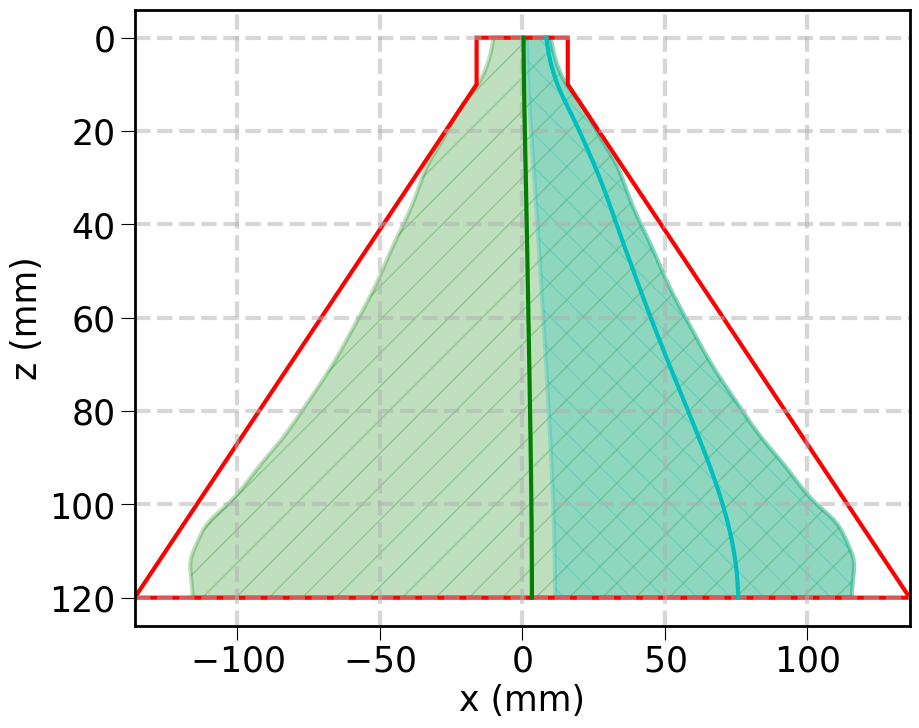

In [78]:
z = np.linspace(-120, 0, 101)


row = reco.loc[16]
print(row.values)

line_lower  = find_line(np.abs(row.anode_lower))
line_center = find_line(np.abs(row.anode      ))
line_upper  = find_line(np.abs(row.anode_upper))

xlower = np.sign(row.anode_lower) * interpolate(line_lower, z)
xupper = np.sign(row.anode_upper) * interpolate(line_upper, z)

plt.plot(interpolate(line_center, z), z, "g-")
plt.fill_betweenx(z, xlower, xupper, hatch="/", color="g", alpha=0.25)
plt.xlabel("x (mm)")
plt.ylabel("z (mm)")


row = reco.loc[25]
print(row.values)

line_lower  = find_line(np.abs(row.anode_lower))
line_center = find_line(np.abs(row.anode      ))
line_upper  = find_line(np.abs(row.anode_upper))

xlower = np.sign(row.anode_lower) * interpolate(line_lower, z)
xupper = np.sign(row.anode_upper) * interpolate(line_upper, z)

plt.plot(interpolate(line_center, z), z, "c-")
plt.fill_betweenx(z, xlower, xupper, hatch="\\", color="c", alpha=0.25)
plt.xlabel("x (mm)")
plt.ylabel("z (mm)")

plt.xlim(-136, 136)

draw_cone()
plt.grid()

In [81]:
line_upper

,r,z,line
8367,115.688859,-1.200000e+02,27000
8368,115.691621,-1.199271e+02,27000
8369,115.697737,-1.197828e+02,27000
8370,115.699312,-1.197487e+02,27000
8371,115.703740,-1.196580e+02,27000
...,...,...,...
11127,10.097954,-1.544629e-01,27000
11128,10.089759,-1.189355e-01,27000
11129,10.081098,-8.109878e-02,27000
11130,10.071705,-3.972963e-02,27000


In [204]:
a = np.linspace(0, 10, 10)
d = (10-0)/9
print(a)
[0 + i*d for i in range(10)]

[ 0.          1.11111111  2.22222222  3.33333333  4.44444444  5.55555556
  6.66666667  7.77777778  8.88888889 10.        ]


[0.0,
 1.1111111111111112,
 2.2222222222222223,
 3.3333333333333335,
 4.444444444444445,
 5.555555555555555,
 6.666666666666667,
 7.777777777777779,
 8.88888888888889,
 10.0]